## 1. 데이터 구조 파악

In [1]:
# 데이터 불러오기
import pandas as pd
df = pd.read_csv('../data/mobile_game_inapp_purchases.csv')

# 데이터 정보
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   UserID                         3024 non-null   object 
 1   Age                            2964 non-null   float64
 2   Gender                         2964 non-null   object 
 3   Country                        2964 non-null   object 
 4   Device                         2964 non-null   object 
 5   GameGenre                      2964 non-null   object 
 6   SessionCount                   3024 non-null   int64  
 7   AverageSessionLength           3024 non-null   float64
 8   SpendingSegment                3024 non-null   object 
 9   InAppPurchaseAmount            2888 non-null   float64
 10  FirstPurchaseDaysAfterInstall  2888 non-null   float64
 11  PaymentMethod                  2888 non-null   object 
 12  LastPurchaseDate               2888 non-null   o

In [2]:
# 데이터 정보
df.shape

(3024, 13)

In [3]:
# 데이터 정보
df.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05


In [4]:
# 결측치 확인
df.isna().sum()

UserID                             0
Age                               60
Gender                            60
Country                           60
Device                            60
GameGenre                         60
SessionCount                       0
AverageSessionLength               0
SpendingSegment                    0
InAppPurchaseAmount              136
FirstPurchaseDaysAfterInstall    136
PaymentMethod                    136
LastPurchaseDate                 136
dtype: int64

In [5]:
# 수치형 컬럼 통계 확인
df.describe()

,Age,SessionCount,AverageSessionLength,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall
count,2964.000000,3024.000000,3024.000000,2888.000000,2888.000000
mean,33.533738,10.074735,20.073978,102.582864,15.384003
std,11.992258,3.115863,8.585208,454.339708,8.946191
min,13.000000,1.000000,5.010000,0.000000,0.000000
25%,23.000000,8.000000,12.680000,5.987500,8.000000
50%,33.000000,10.000000,20.315000,11.975000,16.000000
75%,44.000000,12.000000,27.420000,17.762500,23.000000
max,54.000000,22.000000,34.990000,4964.450000,30.000000


In [6]:
df['Device'].unique()

array(['Android', 'iOS', nan], dtype=object)

In [7]:
df['GameGenre'].unique()

array(['Battle Royale', 'Action RPG', 'Fighting', 'Racing', 'Simulation',
       nan, 'MMORPG', 'Role Playing', 'Sports', 'Card', 'Sandbox',
       'Puzzle', 'Strategy', 'Casual', 'Adventure', 'MOBA'], dtype=object)

In [8]:
df['SpendingSegment'].value_counts()

SpendingSegment
Minnow     2544
Dolphin     412
Whale        68
Name: count, dtype: int64

In [9]:
df['Country'].unique()

array(['Norway', 'Switzerland', 'China', 'Mexico', 'India', 'Italy',
       'Denmark', 'Japan', 'Russia', 'Sweden', 'Australia', 'Turkey',
       'South Korea', 'Saudi Arabia', 'Sri Lanka', 'Canada', 'France',
       'USA', nan, 'UK', 'Netherlands', 'Egypt', 'Spain', 'Brazil',
       'Bangladesh', 'Afghanistan', 'Germany', 'Iran'], dtype=object)

## 2. 전처리

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   UserID                         3024 non-null   object 
 1   Age                            2964 non-null   float64
 2   Gender                         2964 non-null   object 
 3   Country                        2964 non-null   object 
 4   Device                         2964 non-null   object 
 5   GameGenre                      2964 non-null   object 
 6   SessionCount                   3024 non-null   int64  
 7   AverageSessionLength           3024 non-null   float64
 8   SpendingSegment                3024 non-null   object 
 9   InAppPurchaseAmount            2888 non-null   float64
 10  FirstPurchaseDaysAfterInstall  2888 non-null   float64
 11  PaymentMethod                  2888 non-null   object 
 12  LastPurchaseDate               2888 non-null   o

In [11]:
# 나이, 첫 결제까지 걸린 시간 컬럼은 정수 타입으로 변환
df['Age'] = df['Age'].astype('Int64')
df['FirstPurchaseDaysAfterInstall'] = df['FirstPurchaseDaysAfterInstall'].astype('Int64')

# 날짜 타입으로 변환
df['LastPurchaseDate'] = pd.to_datetime(df['LastPurchaseDate'], errors='coerce')

# 범주형 컬럼 -> category 타입 변환
cat_cols = ['Gender','Country','Device','GameGenre','SpendingSegment','PaymentMethod']
for col in cat_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   UserID                         3024 non-null   object        
 1   Age                            2964 non-null   Int64         
 2   Gender                         2964 non-null   category      
 3   Country                        2964 non-null   category      
 4   Device                         2964 non-null   category      
 5   GameGenre                      2964 non-null   category      
 6   SessionCount                   3024 non-null   int64         
 7   AverageSessionLength           3024 non-null   float64       
 8   SpendingSegment                3024 non-null   category      
 9   InAppPurchaseAmount            2888 non-null   float64       
 10  FirstPurchaseDaysAfterInstall  2888 non-null   Int64         
 11  PaymentMethod    

In [12]:
# IsPayer 컬럼 생성
# df['IsPayer'] = df['InAppPurchaseAmount'].apply(lambda x: 1 if pd.notna(x) and x >0 else 0)
df['IsPayer'] = (df['InAppPurchaseAmount']>0).astype(int)
df['IsPayer'].value_counts()

IsPayer
1    2887
0     137
Name: count, dtype: int64

In [13]:
# PlayIntensity 컬럼생성, 세션 카운트 구간화
df['PlayIntensity'] = pd.cut(
    df['SessionCount'],
    bins=[0,8,11,df['SessionCount'].max()],
    labels=['Low','Mid','High']
)
df['PlayIntensity'].value_counts()

PlayIntensity
Mid     1142
Low      949
High     933
Name: count, dtype: int64

In [14]:
# AgeGroup 컬럼생성, 나이 세그먼트 분류
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,19,29,39,49,df['Age'].max()],
    labels=['10s','20s','30s','40s','50+']
)
df['AgeGroup'].value_counts()

AgeGroup
20s    733
40s    714
30s    703
10s    470
50+    344
Name: count, dtype: int64

In [15]:
# SpendingSegment 순서 지정 (Minnow → Dolphin → Whale)
order = ['Minnow','Dolphin','Whale']

df['SpendingSegment'] = df['SpendingSegment'].cat.reorder_categories(
    order,
    ordered=True
)
print(df['SpendingSegment'].cat.categories)
print(df['SpendingSegment'].cat.ordered)

Index(['Minnow', 'Dolphin', 'Whale'], dtype='object')
True


In [16]:
# 이상치 확인
print(df['InAppPurchaseAmount'].describe())
print()
print(df['InAppPurchaseAmount'].quantile([0.9, 0.95, 0.99]))

count    2888.000000
mean      102.582864
std       454.339708
min         0.000000
25%         5.987500
50%        11.975000
75%        17.762500
max      4964.450000
Name: InAppPurchaseAmount, dtype: float64

0.90     214.5760
0.95     375.0155
0.99    2876.6004
Name: InAppPurchaseAmount, dtype: float64


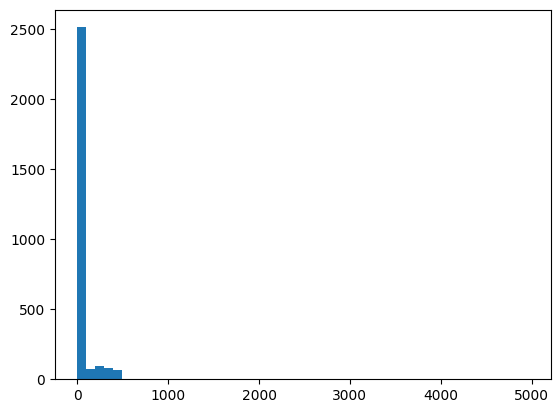

In [17]:
import matplotlib.pyplot as plt
plt.hist(df['InAppPurchaseAmount'].dropna(),bins=50)
plt.show()


count    3024.000000
mean       10.074735
std         3.115863
min         1.000000
25%         8.000000
50%        10.000000
75%        12.000000
max        22.000000
Name: SessionCount, dtype: float64

0.90    14.0
0.95    15.0
0.99    18.0
Name: SessionCount, dtype: float64


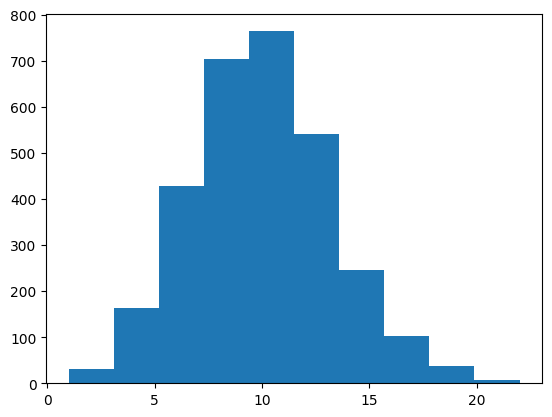

In [18]:
print(df['SessionCount'].describe())
print()
print(df['SessionCount'].quantile([0.9,0.95,0.99]))

plt.hist(df['SessionCount'])
plt.show()

count    3024.000000
mean       20.073978
std         8.585208
min         5.010000
25%        12.680000
50%        20.315000
75%        27.420000
max        34.990000
Name: AverageSessionLength, dtype: float64

0.90    31.7500
0.95    33.3200
0.99    34.6777
Name: AverageSessionLength, dtype: float64


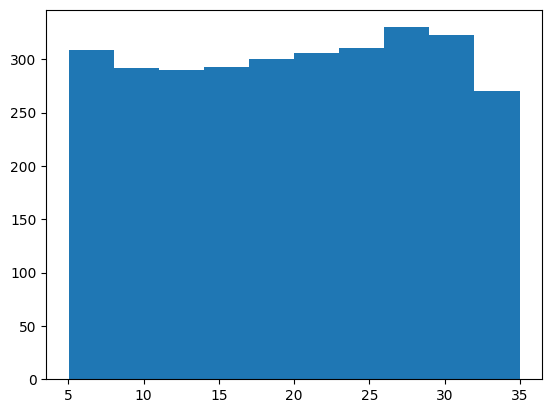

In [19]:
print(df['AverageSessionLength'].describe())
print()
print(df['AverageSessionLength'].quantile([0.9, 0.95, 0.99]))

plt.hist(df['AverageSessionLength'],bins=10)
plt.show()


In [20]:
df['FirstPurchaseDaysAfterInstall'].value_counts().sort_index()

FirstPurchaseDaysAfterInstall
0      83
1      86
2     106
3      99
4      87
5      81
6      82
7      80
8      81
9     100
10    101
11     79
12     85
13     91
14     77
15    104
16     88
17     90
18     97
19    104
20    104
21     93
22     96
23    104
24    103
25    104
26    106
27    102
28     89
29     90
30     96
Name: count, dtype: Int64

## 3. EDA & 비교 분석

In [21]:
# 유저 수 확인
print(df.shape[0]) # 전체 행 수
print(df['UserID'].nunique()) # 유저 id 고유 개수
print(df['UserID'].duplicated().sum()) # 중복 확인

3024
3024
0


In [22]:
# 과금 유저 비율 확인
df['IsPayer'].value_counts(normalize=True)

IsPayer
1    0.954696
0    0.045304
Name: proportion, dtype: float64

In [23]:
# SpendingSegment 분포
df['SpendingSegment'].value_counts(normalize=True)

SpendingSegment
Minnow     0.841270
Dolphin    0.136243
Whale      0.022487
Name: proportion, dtype: float64

In [24]:
# PlayIntensity 분포
df['PlayIntensity'].value_counts(normalize=True)

PlayIntensity
Mid     0.377646
Low     0.313823
High    0.308532
Name: proportion, dtype: float64

Axes(0.125,0.11;0.775x0.77)
15.384002770083102
16.0


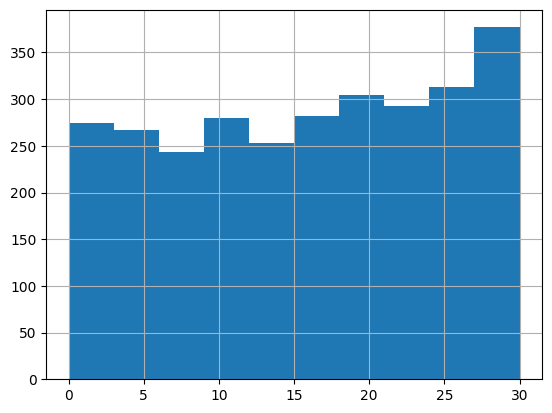

In [25]:
#FirstPurchaseDays 분포
print(df['FirstPurchaseDaysAfterInstall'].hist(bins=10))
print(df['FirstPurchaseDaysAfterInstall'].mean())
print(df['FirstPurchaseDaysAfterInstall'].median())

In [26]:
# PlayIntensity별 평균 SessionCount
df.groupby('PlayIntensity').agg(
    user_cnt=('UserID','count'),
    session_mean=('SessionCount','mean'),

    length_mean=('AverageSessionLength', 'mean'),

)

C:\Users\ksy\AppData\Local\Temp\ipykernel_18540\505525644.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('PlayIntensity').agg(


,user_cnt,session_mean,length_mean
PlayIntensity,,,
Low,949,6.616438,20.088757
Mid,1142,9.989492,20.147215
High,933,13.696677,19.969303


In [27]:
#Device별 평균 SessionCount
df.groupby('Device')['SessionCount'].agg(['count','mean','median'])

C:\Users\ksy\AppData\Local\Temp\ipykernel_18540\3514780824.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Device')['SessionCount'].agg(['count','mean','median'])


,count,mean,median
Device,,,
Android,1738,10.103567,10.0
iOS,1226,10.025285,10.0


In [28]:
#Device별 평균 AverageSessionLength
df.groupby('Device')['AverageSessionLength'].agg(['mean','median'])

C:\Users\ksy\AppData\Local\Temp\ipykernel_18540\2189320958.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Device')['AverageSessionLength'].agg(['mean','median'])


,mean,median
Device,,
Android,19.894724,20.20
iOS,20.359649,20.55


In [29]:
# Device × High 비율
pd.crosstab(df['Device'], df['PlayIntensity'], normalize='index')

PlayIntensity,Low,Mid,High
Device,,,
Android,0.302647,0.395282,0.302071
iOS,0.333605,0.348287,0.318108


In [30]:
#Device별 평균 과금 금액
df.groupby('Device')['InAppPurchaseAmount'].agg(['count','mean','median'])

C:\Users\ksy\AppData\Local\Temp\ipykernel_18540\3930529357.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Device')['InAppPurchaseAmount'].agg(['count','mean','median'])


,count,mean,median
Device,,,
Android,1666,94.670834,11.565
iOS,1166,111.052847,12.835


In [31]:
# Device × SpendingSegment 비율
pd.crosstab(df['Device'], df['SpendingSegment'], normalize='index')

SpendingSegment,Minnow,Dolphin,Whale
Device,,,
Android,0.844649,0.134062,0.021289
iOS,0.838499,0.139478,0.022023


In [32]:
#Device별 총 매출 비중
df.groupby('Device')['InAppPurchaseAmount'].sum()

C:\Users\ksy\AppData\Local\Temp\ipykernel_18540\1869793456.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Device')['InAppPurchaseAmount'].sum()


Device
Android    157721.61
iOS        129487.62
Name: InAppPurchaseAmount, dtype: float64

In [33]:
#AgeGroup별 평균 SessionCount
df.groupby('AgeGroup')['SessionCount'].agg(['count','mean','median'])

C:\Users\ksy\AppData\Local\Temp\ipykernel_18540\3769708542.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['SessionCount'].agg(['count','mean','median'])


,count,mean,median
AgeGroup,,,
10s,470,9.804255,10.0
20s,733,10.053206,10.0
30s,703,10.150782,10.0
40s,714,10.120448,10.0
50+,344,10.180233,10.0


In [34]:
# AgeGroup별 평균 AverageSessionLength
df.groupby('AgeGroup')['AverageSessionLength'].agg(['mean','median'])

C:\Users\ksy\AppData\Local\Temp\ipykernel_18540\2757072924.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['AverageSessionLength'].agg(['mean','median'])


,mean,median
AgeGroup,,
10s,20.087723,19.560
20s,20.179932,20.640
30s,20.068535,20.620
40s,20.085700,20.170
50+,19.773576,19.645


In [35]:
#AgeGroup × PlayIntensity 비율
pd.crosstab(df['AgeGroup'], df['PlayIntensity'], normalize='index')

PlayIntensity,Low,Mid,High
AgeGroup,,,
10s,0.331915,0.391489,0.276596
20s,0.317872,0.380628,0.301501
30s,0.307255,0.376956,0.315789
40s,0.320728,0.365546,0.313725
50+,0.299419,0.363372,0.337209


In [36]:
#PlayIntensity별 평균 과금 금액
df.groupby('PlayIntensity')['InAppPurchaseAmount'].agg(['count','mean','median'])

C:\Users\ksy\AppData\Local\Temp\ipykernel_18540\4237725538.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('PlayIntensity')['InAppPurchaseAmount'].agg(['count','mean','median'])


,count,mean,median
PlayIntensity,,,
Low,910,73.404582,11.745
Mid,1091,107.808323,11.980
High,887,126.090485,12.370


In [37]:
#PlayIntensity × SpendingSegment 비율
pd.crosstab(df['PlayIntensity'], df['SpendingSegment'], normalize='index')

SpendingSegment,Minnow,Dolphin,Whale
PlayIntensity,,,
Low,0.857745,0.128556,0.013699
Mid,0.839755,0.138354,0.021891
High,0.826367,0.141479,0.032154


In [38]:
#PlayIntensity별 총 매출 기여도
df.groupby('PlayIntensity')['InAppPurchaseAmount'].sum()

C:\Users\ksy\AppData\Local\Temp\ipykernel_18540\4058360401.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('PlayIntensity')['InAppPurchaseAmount'].sum()


PlayIntensity
Low      66798.17
Mid     117618.88
High    111842.26
Name: InAppPurchaseAmount, dtype: float64

In [39]:
# 파일저장
df.to_csv('clean_mobile_game_data.csv',index=False,encoding="utf-8-sig")